### Color-magntidue diagram practice

In [15]:
# import packages
from astropy.table import Table 
from astropy import units as u
import numpy as np
from astroquery.svo_fps import SvoFps

#https://docs.astropy.org/en/stable/table/index.html
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits') # import JWST catalog file

# choose sources with more than 3 matched bands
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]






### explore the catalog file 


In [16]:
catalog.pprint(10, max_width=-1)

             skycoord_ref             skycoord_ref_filtername       sep_f140m        id_f140m             skycoord_f140m              flux_fit_f140m     flux_err_f140m   mask_f140m      qfit_f140m           cfit_f140m        local_bkg_f140m      roundness1_f140m      roundness2_f140m   sharpness_f140m   from_sat_catalog_f140m      std_ra_f140m          std_dec_f140m     nmatch_f140m nmatch_good_f140m flux_err_prop_f140m       sep_f162m        id_f162m             skycoord_f162m              flux_fit_f162m     flux_err_f162m   mask_f162m      qfit_f162m             cfit_f162m        local_bkg_f162m      roundness1_f162m     roundness2_f162m    sharpness_f162m   from_sat_catalog_f162m      std_ra_f162m          std_dec_f162m      nmatch_f162m nmatch_good_f162m flux_err_prop_f162m       sep_f182m        id_f182m             skycoord_f182m              flux_fit_f182m     flux_err_f182m   mask_f182m      qfit_f182m            cfit_f182m       local_bkg_f182m     roundness1_f182m     roundne

In [17]:

def get_mag(catalog, ww, filtername='f140m' ):
    """
    Calculate Vega and AB magnitudes from fluxes in the catalog for a given filter.
    Parameters:
    - catalog: Astropy Table containing the flux and flux error columns.   
    - ww: World Coordinate System (WCS) object for the image, used to calculate pixel area.
    - filtername: String name of the filter (e.g., 'f140m').
    Returns:
    - vegamag: Vega magnitude.
    - vegamag_err: Error in Vega magnitude.
    - abmag: AB magnitude.
    - abmag_err: Error in AB magnitude.
    """
    # get flux and flux error from the catalog, convert to Jy
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    # Get the filter information from SVO Filter Profile Service
    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err # return Vega magnitude, Vega magnitude error, AB magnitude, AB magnitude error
    







In [ ]:
from astropy.io import fits
from astropy.wcs import WCS

#JWST image filenames for each filter
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", 
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

# Get the WCS information from the FITS headers for each filter
f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))


# Calculate magnitudes for each filter using the get_mag function
f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')


magnitudes = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-0

# plot color-magnitude diagram

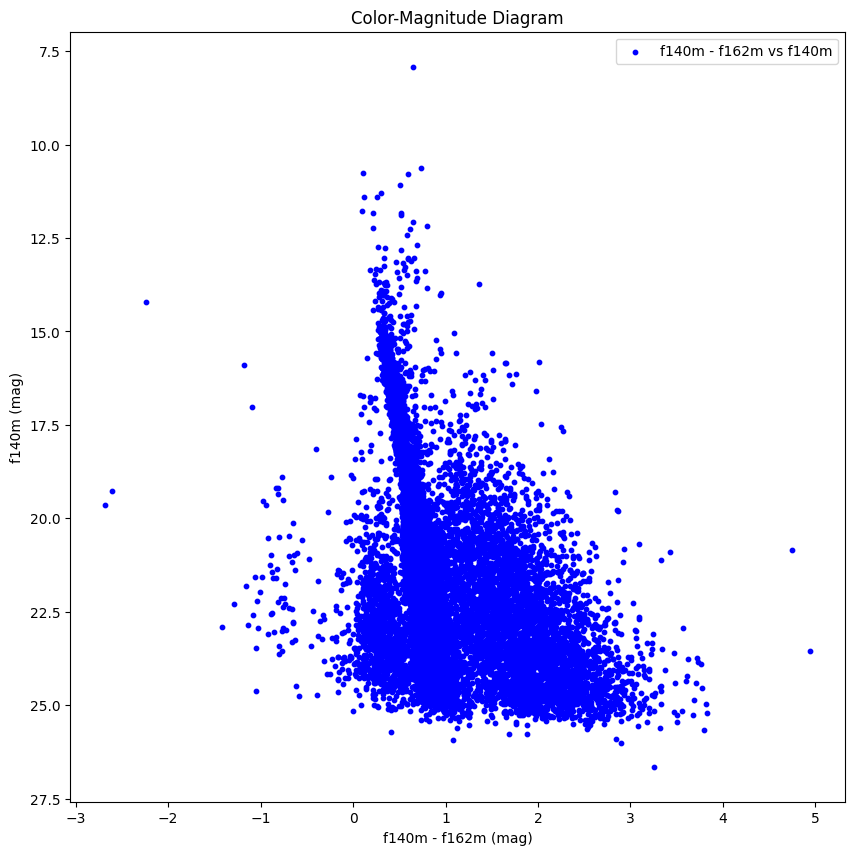

In [19]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
color = magnitudes['f140m'][0] - magnitudes['f162m'][0]
magnitude = magnitudes['f140m'][0]

ax.scatter(color, magnitude, s=10, c='blue', label='f140m - f162m vs f140m')
ax.set_xlabel('f140m - f162m (mag)')
ax.set_ylabel('f140m (mag)')
ax.set_title('Color-Magnitude Diagram')
ax.invert_yaxis()  # Invert y-axis for magnitudes
ax.legend()
plt.show()

